#### Load and resize image

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift


In [18]:
image = data.camera()
image = resize(image, (256, 256)) 

M, N = image.shape

#### Define Sobel filters

In [19]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

#### Function for padding and centering of kernel 

In [12]:
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    
    return fft2(ifftshift(padded))  # Shift before FFT to place (0,0) at top-left


#### Compute FFT of the image and the FFt of centered Sobel filters

In [24]:
F_image = fft2(image)

H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

#### Multiply in the frequency domain then inverse the FFT to get spatial results

In [22]:
G_x = F_image * H_x
G_y = F_image * H_y

grad_x = ifft2(G_x).real
grad_y = ifft2(G_y).real



#### Compute Gradient Magnitude

In [ ]:
grad_mag = np.sqrt(grad_x**2 + grad_y**2)

#### Plot results

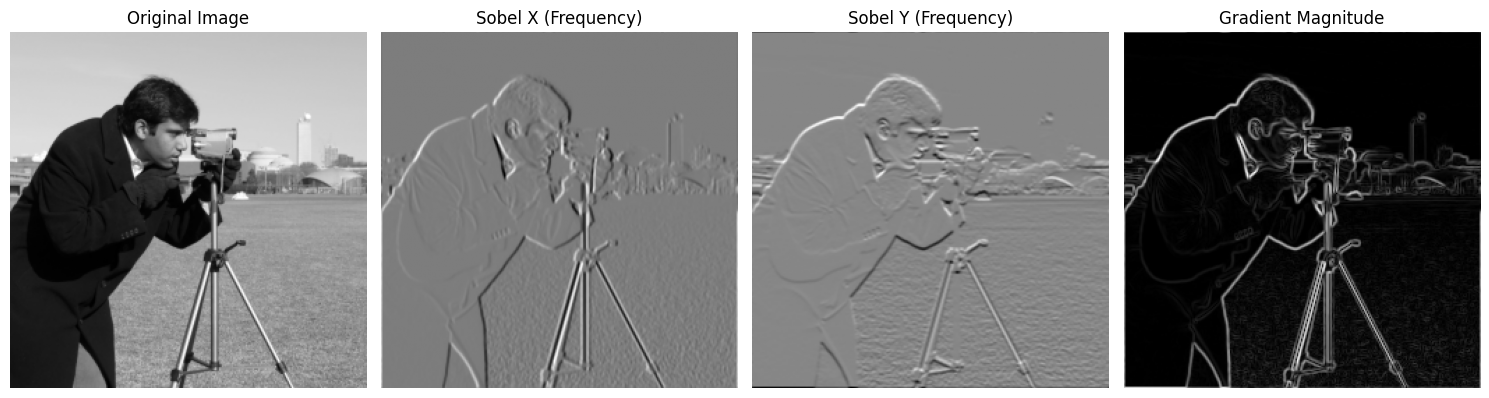

In [27]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(grad_x, cmap='gray')
plt.title('Sobel X (Frequency)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(grad_y, cmap='gray')
plt.title('Sobel Y (Frequency)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(grad_mag, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()